In [1]:
print("hello")

hello


In [75]:
#패키지 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

#폰트설정
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [76]:
health_data = pd.read_csv('smoking_health_data.csv')
health_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        7000 non-null   str    
 1   나이        7000 non-null   int64  
 2   키(cm)     7000 non-null   int64  
 3   몸무게(kg)   7000 non-null   int64  
 4   BMI       7000 non-null   float64
 5   시력        6860 non-null   float64
 6   충치        7000 non-null   int64  
 7   공복 혈당     6860 non-null   float64
 8   혈압        6860 non-null   float64
 9   중성 지방     6860 non-null   float64
 10  혈청 크레아티닌  7000 non-null   float64
 11  콜레스테롤     7000 non-null   int64  
 12  고밀도지단백    7000 non-null   int64  
 13  저밀도지단백    7000 non-null   int64  
 14  헤모글로빈     7000 non-null   float64
 15  요 단백      7000 non-null   int64  
 16  간 효소율     7000 non-null   float64
 17  label     7000 non-null   int64  
dtypes: float64(8), int64(9), str(1)
memory usage: 984.5 KB


### 데이터 전처리

- 결측치와 이상치는 분석 결과에 영향을 줄 수 있으므로 적절한 기준에 따라 처리하였다.

In [77]:
# 중복 확인
print(f"중복 데이터: {health_data.duplicated(subset=health_data.columns.difference(['ID'])).sum()}쌍")

# 중복 제거
health_data = health_data.drop_duplicates(
    subset=health_data.columns.difference(['ID']),
    keep='first'
).reset_index(drop=True)

print(f"제거 전: 7000건")
print(f"제거 후: {len(health_data)}건")

중복 데이터: 166쌍
제거 전: 7000건
제거 후: 6834건


In [81]:
round(health_data.describe(),2)

,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
count,6834.00,6834.00,6834.00,6834.00,6694.00,6834.00,6694.00,6694.00,6694.00,6834.00,6834.00,6834.00,6834.00,6834.00,6834.00,6834.00,6834.00
mean,43.99,164.78,65.95,24.15,1.01,0.23,99.34,45.57,127.12,0.89,197.29,57.34,115.39,14.63,1.08,1.15,0.37
std,12.08,9.19,12.98,3.50,0.43,0.42,21.20,8.84,73.28,0.24,36.42,14.46,42.02,1.54,0.39,0.43,0.48
min,20.00,135.00,30.00,14.27,0.10,0.00,57.00,14.00,21.00,0.10,86.00,18.00,1.00,4.90,1.00,0.14,0.00
25%,35.00,160.00,55.00,21.60,0.80,0.00,89.00,40.00,74.00,0.80,173.00,47.00,92.00,13.60,1.00,0.84,0.00
50%,40.00,165.00,65.00,23.88,1.00,0.00,96.00,45.00,107.00,0.90,195.00,55.00,113.00,14.80,1.00,1.10,0.00
75%,50.00,170.00,75.00,26.12,1.20,0.00,104.00,50.00,161.00,1.00,219.00,66.00,136.00,15.70,1.00,1.38,1.00
max,85.00,190.00,130.00,42.45,9.90,1.00,386.00,91.00,399.00,10.00,395.00,157.00,1340.00,20.90,5.00,5.67,1.00


In [78]:
#bmi 구간 컬럼 추가
bins = [0, 18.5, 23, 25, 30, 35, float("inf")]
labels = ["저체중", "정상", "비만전단계", "1단계 비만", "2단계 비만", "3단계 비만"]
health_data["BMI 구간"] = pd.cut(health_data["BMI"], bins, labels=labels,right = False)

In [79]:
#나이대 컬럼 추가
bins = [20,30,40,50,60,70,80,float("inf")]
labels = ['20대','30대','40대','50대','60대','70대','70대 초과']
health_data["나이대"] = pd.cut(health_data["나이"], bins, labels=labels,right = False)

In [80]:
#결측치 수 확인
missing_count = health_data.isnull().sum()
print("컬럼별 결측치 개수:")
print(missing_count)

컬럼별 결측치 개수:
ID            0
나이            0
키(cm)         0
몸무게(kg)       0
BMI           0
시력          140
충치            0
공복 혈당       140
혈압          140
중성 지방       140
혈청 크레아티닌      0
콜레스테롤         0
고밀도지단백        0
저밀도지단백        0
헤모글로빈         0
요 단백          0
간 효소율         0
label         0
BMI 구간        0
나이대           0
dtype: int64


In [50]:
#결측치 대체
health_data["혈압"] = health_data["혈압"].fillna(health_data["혈압"].median())
health_data["시력"] = health_data["시력"].fillna(health_data["시력"].mode()[0])
health_data["공복 혈당"] = health_data["공복 혈당"].fillna(health_data["공복 혈당"].mean())
health_age_group = health_data.groupby(by="나이대")
health_data['중성 지방'] = health_data['중성 지방'].fillna(health_age_group['중성 지방'].transform('mean'))

In [51]:
#결측치 재확인
missing_count = health_data.isnull().sum()
print("컬럼별 결측치 개수:")
print(missing_count)

컬럼별 결측치 개수:
ID          0
나이          0
키(cm)       0
몸무게(kg)     0
BMI         0
시력          0
충치          0
공복 혈당       0
혈압          0
중성 지방       0
혈청 크레아티닌    0
콜레스테롤       0
고밀도지단백      0
저밀도지단백      0
헤모글로빈       0
요 단백        0
간 효소율       0
label       0
BMI 구간      0
나이대         0
dtype: int64


In [52]:
#이상치 대체
health_data.loc[health_data['시력']>3, '시력'] = None
health_data.loc[health_data['혈청 크레아티닌']>8, '혈청 크레아티닌'] = None
health_data.loc[health_data['저밀도지단백']>500, '저밀도지단백'] = None

In [54]:
health_data['저밀도지단백'] = (health_data
                         .groupby(by = '나이대')['저밀도지단백']
                         .transform(lambda x : x.fillna(x.median()))
                         )
health_data['시력'] = health_data['시력'].fillna(health_data['시력'].mode()[0])
health_data['혈청 크레아티닌'] = health_data['혈청 크레아티닌'].fillna(health_data['혈청 크레아티닌'].median())

In [55]:
#가설 수립
# 가설 1. Hb
# H₀ (귀무가설): 흡연자와 비흡연자의 평균 헤모글로빈 수치는 같다.
# H₁ (대립가설): 흡연자와 비흡연자의 평균 헤모글로빈 수치는 다르다.
# 가설 2.Triglyceride
# H₀ (귀무가설): 흡연자와 비흡연자의 평균 중성 지방 수치는 같다.
# H₁ (대립가설): 흡연자와 비흡연자의 평균 중성 지방 수치는 다르다.
# 가설 3.Serum Creatinine
# H₀ (귀무가설): 흡연자와 비흡연자의 평균 혈청 크레아티닌 수치는 같다.
# H₁ (대립가설): 흡연자와 비흡연자의 평균 혈청 크레아티닌 수치는 다르다.

In [56]:
health_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6834 entries, 0 to 6833
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   ID        6834 non-null   str     
 1   나이        6834 non-null   int64   
 2   키(cm)     6834 non-null   int64   
 3   몸무게(kg)   6834 non-null   int64   
 4   BMI       6834 non-null   float64 
 5   시력        6834 non-null   float64 
 6   충치        6834 non-null   int64   
 7   공복 혈당     6834 non-null   float64 
 8   혈압        6834 non-null   float64 
 9   중성 지방     6834 non-null   float64 
 10  혈청 크레아티닌  6834 non-null   float64 
 11  콜레스테롤     6834 non-null   int64   
 12  고밀도지단백    6834 non-null   int64   
 13  저밀도지단백    6834 non-null   float64 
 14  헤모글로빈     6834 non-null   float64 
 15  요 단백      6834 non-null   int64   
 16  간 효소율     6834 non-null   float64 
 17  label     6834 non-null   int64   
 18  BMI 구간    6834 non-null   category
 19  나이대       6834 non-null   category
dtypes: category(2), flo

### 단변량 분석

In [57]:
# 범주형 자료와 연속형 자료를 구분하기위해 type 변경
health_data['label'] = health_data['label'].astype('category')
health_data['충치'] = health_data['충치'].astype('category')
health_data['요 단백'] = health_data['요 단백'].astype('category')


===============나이=================
결측치 수: 0
count    6834.000000
mean       43.991806
std        12.084472
min        20.000000
25%        35.000000
50%        40.000000
75%        50.000000
max        85.000000
Name: 나이, dtype: float64


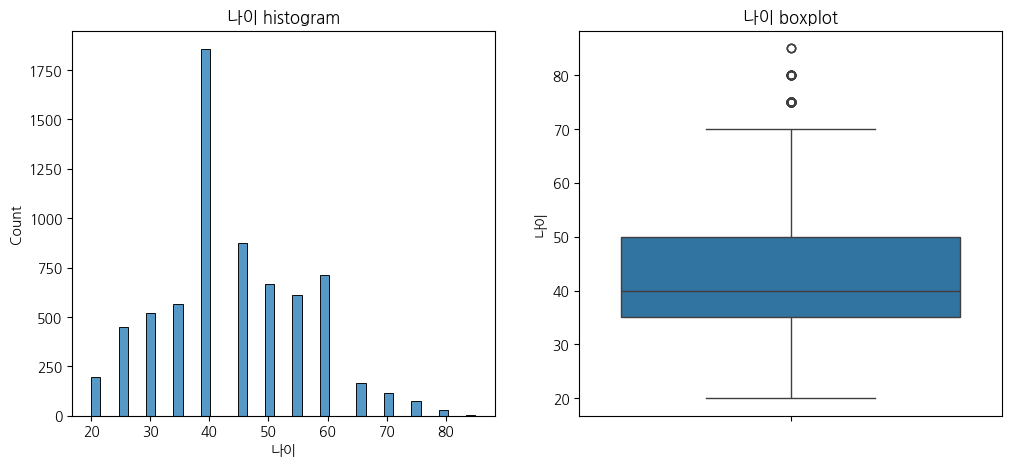


===============키(cm)=================
결측치 수: 0
count    6834.000000
mean      164.783436
std         9.187539
min       135.000000
25%       160.000000
50%       165.000000
75%       170.000000
max       190.000000
Name: 키(cm), dtype: float64


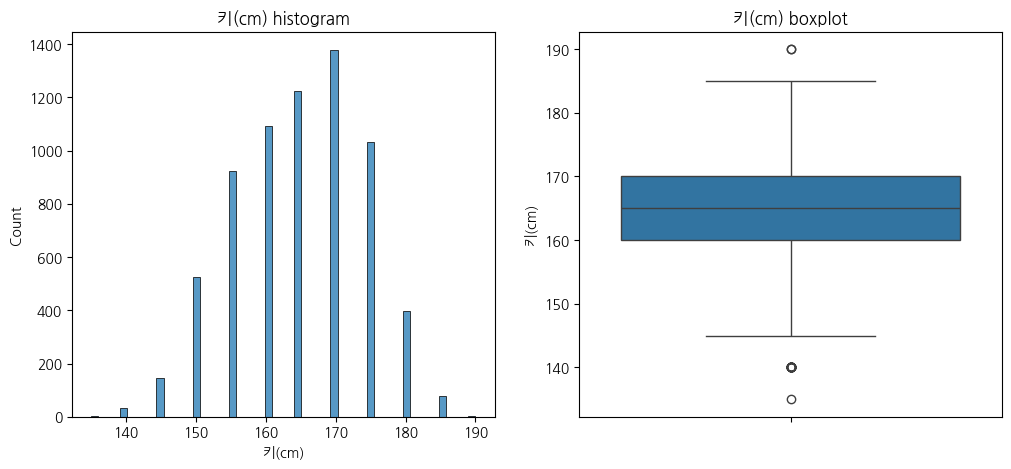


===============몸무게(kg)=================
결측치 수: 0
count    6834.000000
mean       65.951127
std        12.978258
min        30.000000
25%        55.000000
50%        65.000000
75%        75.000000
max       130.000000
Name: 몸무게(kg), dtype: float64


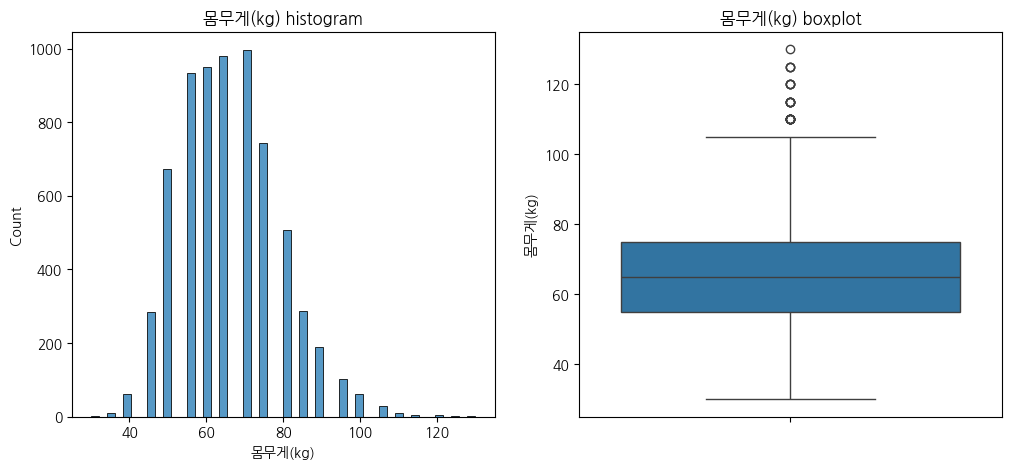


===============BMI=================
결측치 수: 0
count    6834.000000
mean       24.150613
std         3.499222
min        14.270000
25%        21.600000
50%        23.880000
75%        26.120000
max        42.450000
Name: BMI, dtype: float64


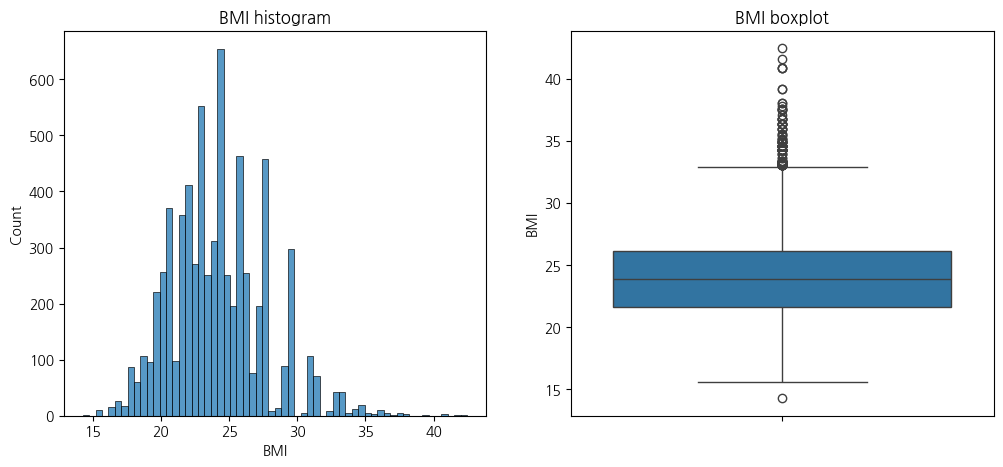


===============시력=================
결측치 수: 0
count    6834.000000
mean        0.997022
std         0.299139
min         0.100000
25%         0.800000
50%         1.000000
75%         1.200000
max         2.000000
Name: 시력, dtype: float64


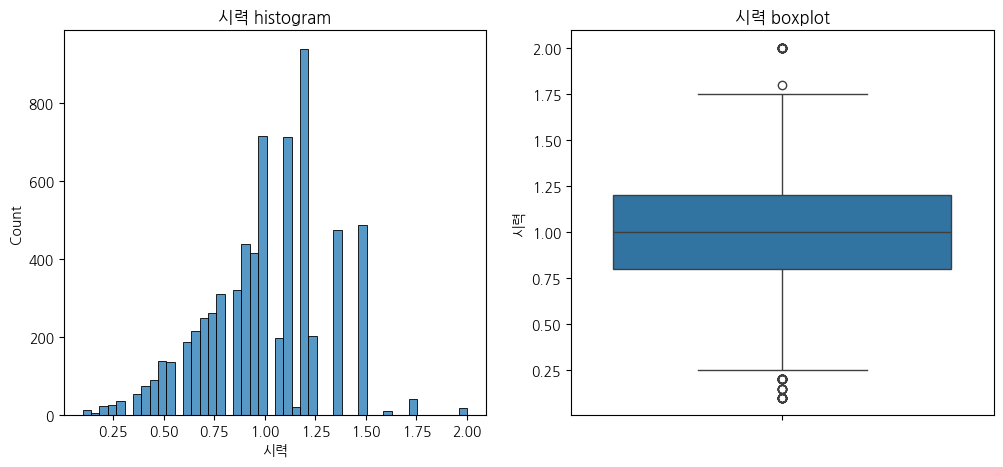


===============공복 혈당=================
결측치 수: 0
count    6834.000000
mean       99.340902
std        20.982469
min        57.000000
25%        89.000000
50%        96.000000
75%       103.000000
max       386.000000
Name: 공복 혈당, dtype: float64


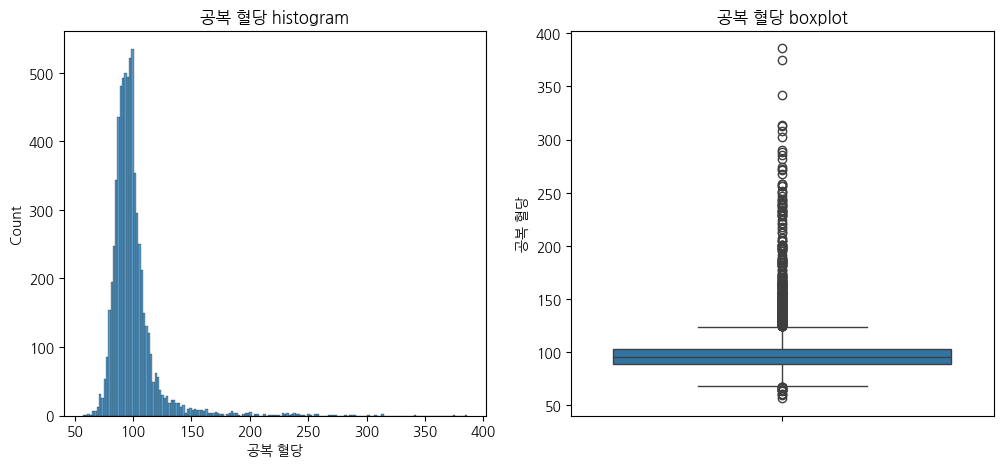


===============혈압=================
결측치 수: 0
count    6834.000000
mean       45.561018
std         8.749711
min        14.000000
25%        40.000000
50%        45.000000
75%        50.000000
max        91.000000
Name: 혈압, dtype: float64


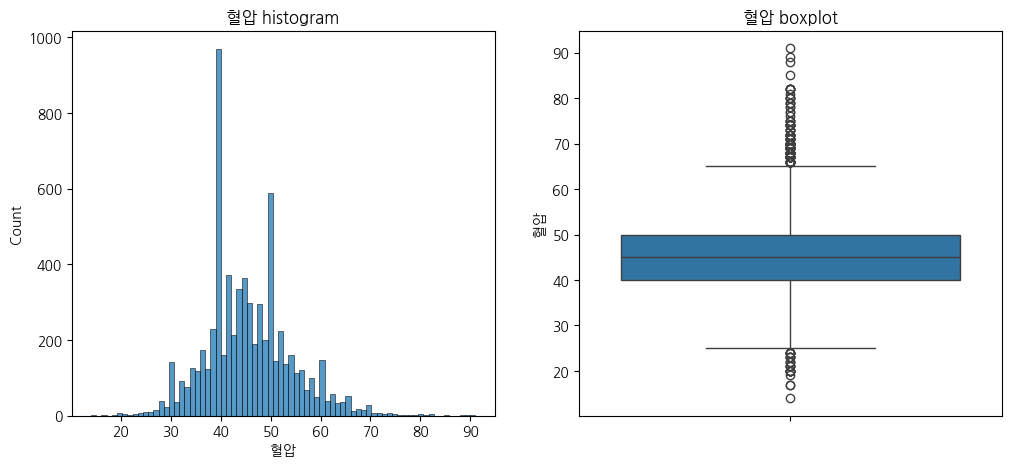


===============중성 지방=================
결측치 수: 0
count    6834.000000
mean      127.110388
std        72.532643
min        21.000000
25%        74.000000
50%       108.000000
75%       160.000000
max       399.000000
Name: 중성 지방, dtype: float64


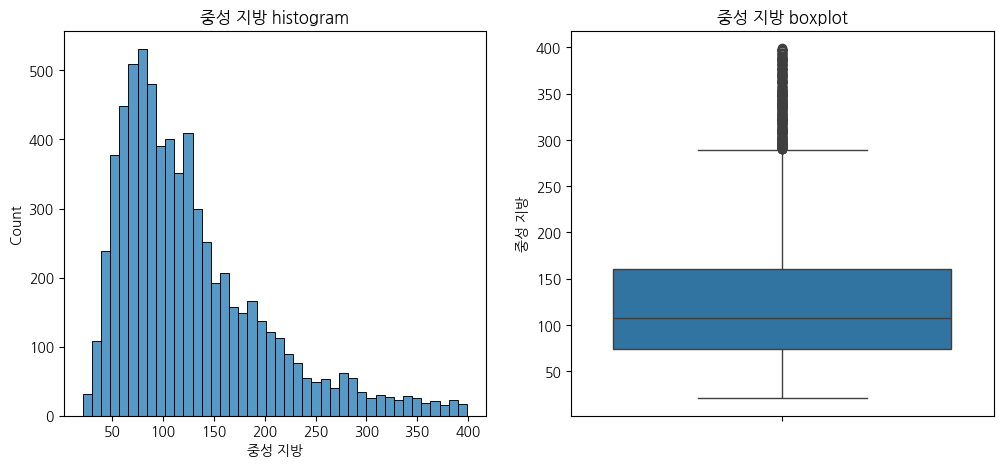


===============혈청 크레아티닌=================
결측치 수: 0
count    6834.000000
mean        0.884050
std         0.216143
min         0.100000
25%         0.800000
50%         0.900000
75%         1.000000
max         7.400000
Name: 혈청 크레아티닌, dtype: float64


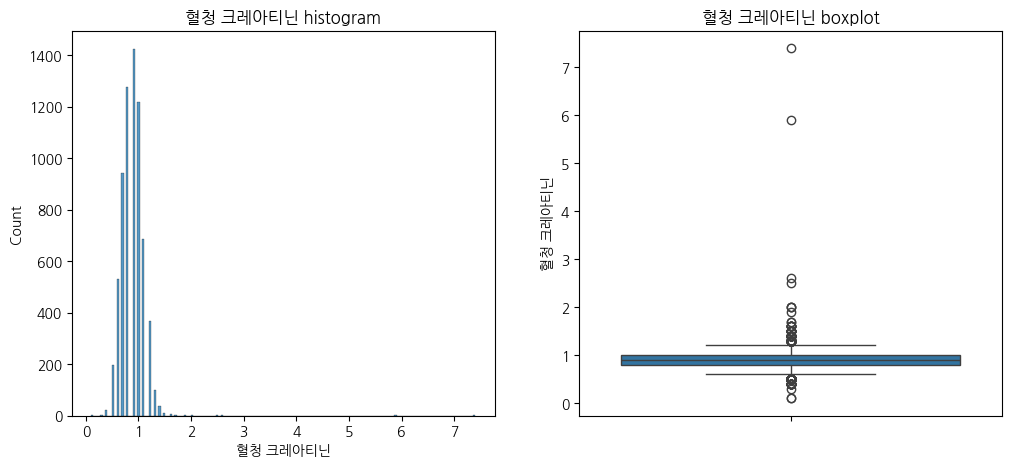


===============콜레스테롤=================
결측치 수: 0
count    6834.000000
mean      197.294557
std        36.422272
min        86.000000
25%       173.000000
50%       195.000000
75%       219.000000
max       395.000000
Name: 콜레스테롤, dtype: float64


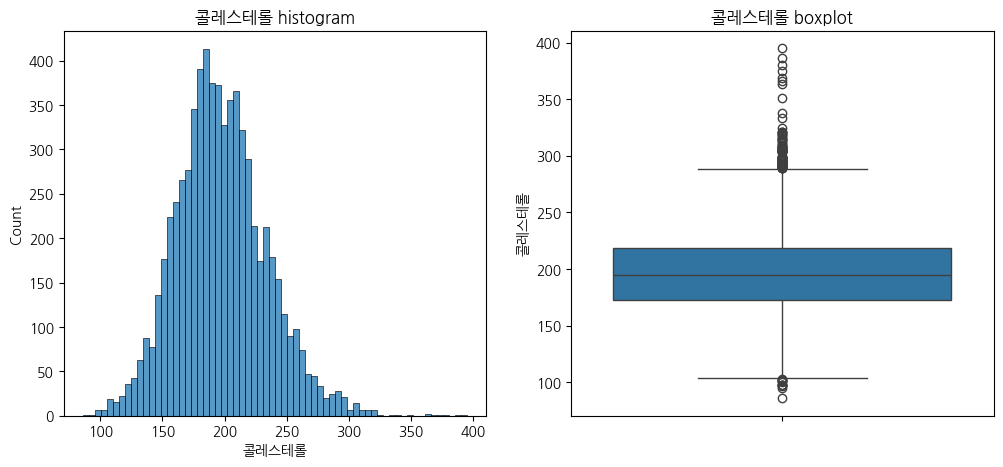


===============고밀도지단백=================
결측치 수: 0
count    6834.000000
mean       57.337284
std        14.464112
min        18.000000
25%        47.000000
50%        55.000000
75%        66.000000
max       157.000000
Name: 고밀도지단백, dtype: float64


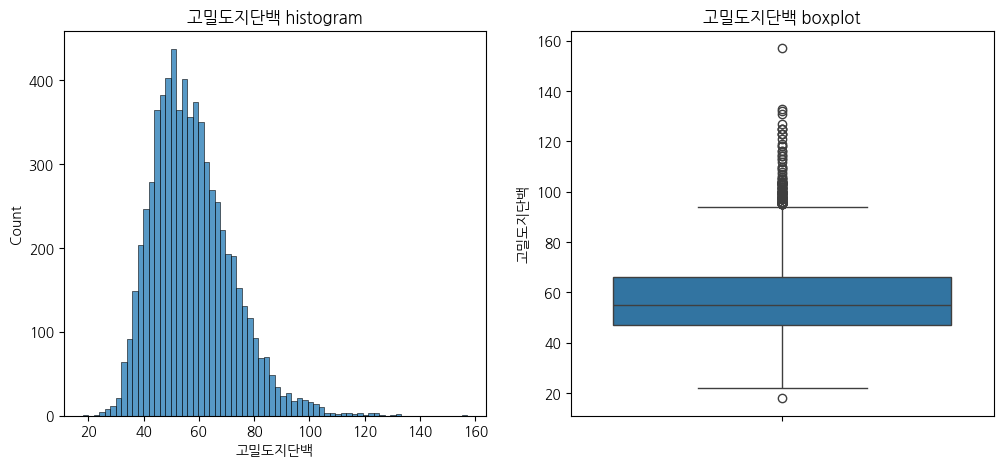


===============저밀도지단백=================
결측치 수: 0
count    6834.000000
mean      114.730100
std        33.751408
min         1.000000
25%        92.000000
50%       113.000000
75%       136.000000
max       307.000000
Name: 저밀도지단백, dtype: float64


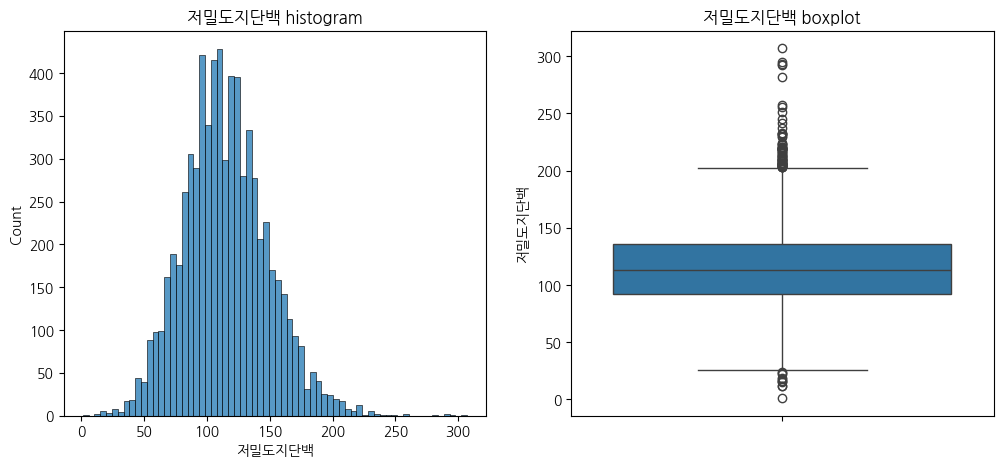


===============헤모글로빈=================
결측치 수: 0
count    6834.000000
mean       14.634080
std         1.542088
min         4.900000
25%        13.600000
50%        14.800000
75%        15.700000
max        20.900000
Name: 헤모글로빈, dtype: float64


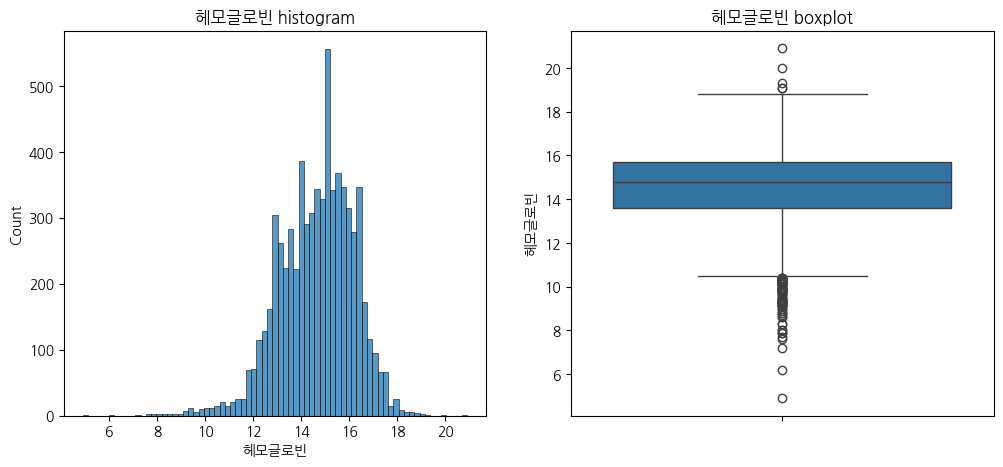


===============간 효소율=================
결측치 수: 0
count    6834.000000
mean        1.145007
std         0.433854
min         0.140000
25%         0.840000
50%         1.100000
75%         1.380000
max         5.670000
Name: 간 효소율, dtype: float64


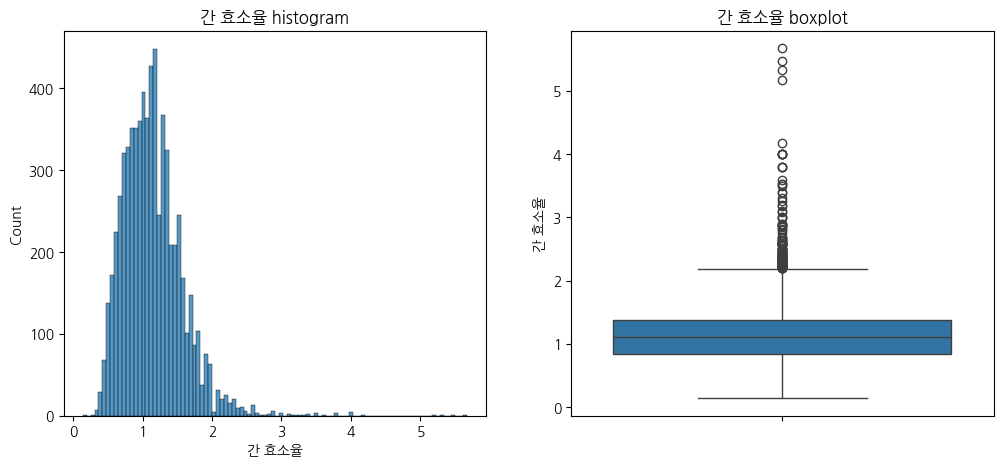

In [58]:
#연속형 자료들의 단변량 분석
numeric_cols = health_data.select_dtypes(include='number').columns
for col in numeric_cols:
    print(f"\n==============={col}=================")
    print(f"결측치 수: {health_data[col].isnull().sum()}")
    print(health_data[col].describe())
    plt.figure(figsize=(12, 5))

    #hist
    plt.subplot(1, 2, 1)
    sns.histplot(health_data[col])
    plt.title(f"{col} histogram")

    #boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(data=health_data[col])
    plt.title(f"{col} boxplot")
    plt.show()

In [71]:
health_data.describe()

,나이,키(cm),몸무게(kg),BMI,시력,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,간 효소율
count,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000
mean,43.991806,164.783436,65.951127,24.150613,0.997022,99.340902,45.561018,127.110388,0.884050,197.294557,57.337284,114.730100,14.634080,1.145007
std,12.084472,9.187539,12.978258,3.499222,0.299139,20.982469,8.749711,72.532643,0.216143,36.422272,14.464112,33.751408,1.542088,0.433854
min,20.000000,135.000000,30.000000,14.270000,0.100000,57.000000,14.000000,21.000000,0.100000,86.000000,18.000000,1.000000,4.900000,0.140000
25%,35.000000,160.000000,55.000000,21.600000,0.800000,89.000000,40.000000,74.000000,0.800000,173.000000,47.000000,92.000000,13.600000,0.840000
50%,40.000000,165.000000,65.000000,23.880000,1.000000,96.000000,45.000000,108.000000,0.900000,195.000000,55.000000,113.000000,14.800000,1.100000
75%,50.000000,170.000000,75.000000,26.120000,1.200000,103.000000,50.000000,160.000000,1.000000,219.000000,66.000000,136.000000,15.700000,1.380000
max,85.000000,190.000000,130.000000,42.450000,2.000000,386.000000,91.000000,399.000000,7.400000,395.000000,157.000000,307.000000,20.900000,5.670000



===== 충치 =====
충치
0    5271
1    1563
Name: count, dtype: int64


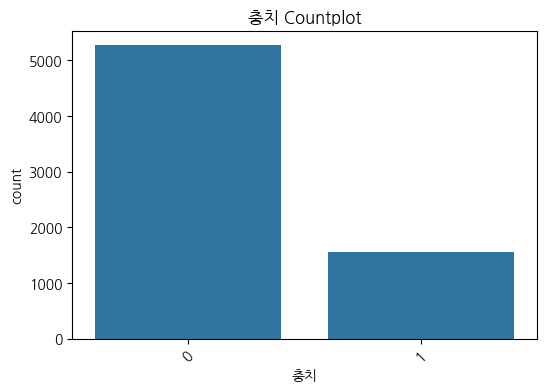


===== 요 단백 =====
요 단백
1    6458
2     227
3     105
4      34
5      10
Name: count, dtype: int64


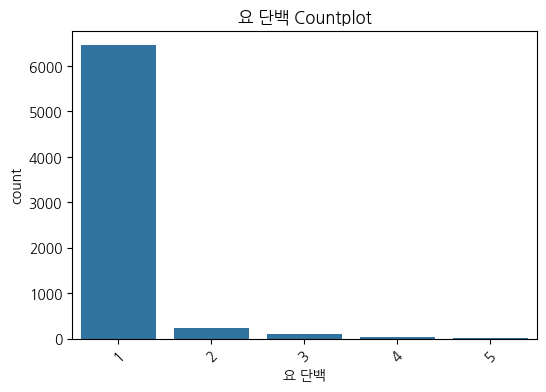


===== label =====
label
0    4323
1    2511
Name: count, dtype: int64


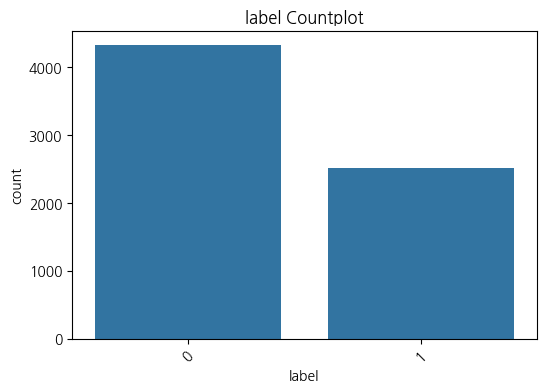


===== BMI 구간 =====
BMI 구간
정상        2665
1단계 비만    2052
비만전단계     1543
2단계 비만     314
저체중        221
3단계 비만      39
Name: count, dtype: int64


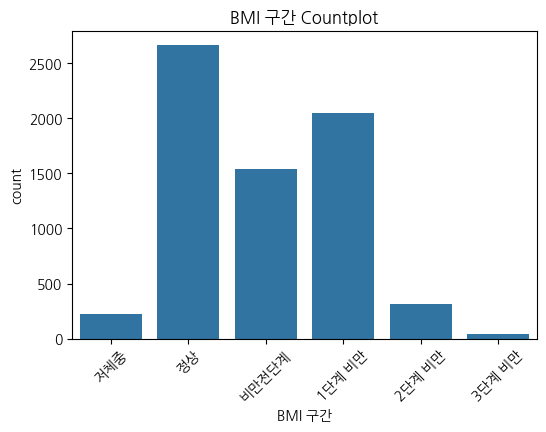


===== 나이대 =====
나이대
40대       2730
50대       1277
30대       1085
60대        876
20대        643
70대        191
70대 초과      32
Name: count, dtype: int64


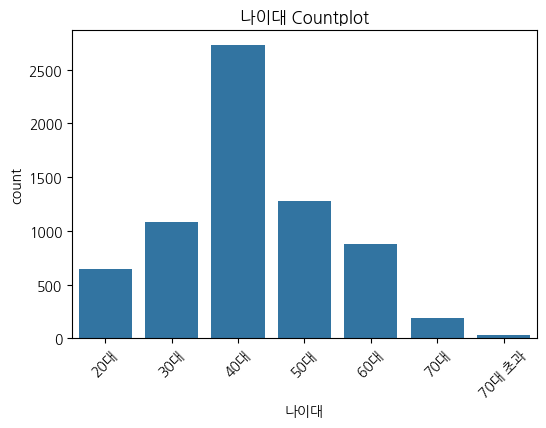

In [59]:
#범주형 변수들의 단변량 분석
categorical_cols = health_data.select_dtypes(include='category').columns

for col in categorical_cols:

    print(f"\n===== {col} =====")

    print(health_data[col].value_counts())

    plt.figure(figsize=(6, 4))

    sns.countplot(
        data=health_data,
        x=col
    )

    plt.title(f"{col} Countplot")
    plt.xticks(rotation=45)
    plt.show()

## 데이터 품질 및 단변량 분석 요약

### 1. 데이터 품질 및 전처리 요약

전처리는 중복치 제거 → 이상치 처리 → 결측치 대체 순서로 진행하였다.

| 단계 | 처리 내용 | 결과 |
|------|-----------|------|
| 중복치 제거 | ID 제외 전 컬럼 기준 완전 일치 행 제거 | 7,000건 → **6,834건** (166건 제거) |
| 이상치 처리 | 시력 > 3.0, 혈청 크레아티닌 > 8.0, 저밀도지단백 > 500 → None 처리 | 극단값 제거 |
| 결측치 대체 | 시력 → 최빈값, 혈청 크레아티닌 → 전체 중앙값, 저밀도지단백·중성 지방 → 나이대별 중앙값/평균, 공복 혈당 → 전체 평균, 혈압 → 전체 중앙값 | 결측치 0건 |

최종 데이터는 **6,834건, 20개 컬럼**으로 결측치 없이 모델링에 활용 가능한 상태이다.

---

### 2. 타겟 변수(label) 분포

| 클래스 | 의미 | 비율 |
|--------|------|------|
| 0 | 비흡연자 | 약 63% |
| 1 | 흡연자 | 약 37% |

약 63:37로 완전한 균형은 아니지만 심각한 불균형 수준은 아니다.

---

### 3. BMI 분포

| BMI 구간 | 기준(WHO) | 분포 특징 |
|----------|-----------|-----------|
| 저체중 | < 18.5 | 소수 |
| 정상 | 18.5 이상 23.0 미만 | 일부 |
| 비만 전단계 이상 | ≥ 23.0 | **과반 이상 — 우세** |

비만 전단계 이상 집단이 정상 체중 이하 집단보다 많아, 데이터 전반적으로 체중 관련 건강 위험 요인을 포함한다. BMI 평균은 24.15로 비만 전단계에 해당하며, 흡연 여부 예측의 설명 변수로 충분히 활용 가능하다.

---

### 4. 나이 분포

| 연령대 | 구성 비율 | 비고 |
|--------|-----------|------|
| 20대~30대 | 일부 | |
| 40대~50대 | **가장 많음** | 분석의 중심 집단 |
| 60대 이상 | 상대적으로 적음 | 고령층 일반화 시 주의 |

나이 평균은 약 44세로 40대 중심 중년층 데이터이다. 고령층에 대한 일반화는 제한될 수 있다.

---

### 5. 주요 건강 지표 이상치 처리

분포 확인 결과, 일부 변수에서 현실적으로 불가능한 극단값이 관찰되어 아래와 같이 처리하였다.

| 변수 | 기준 | 처리 방법 | 대체값 |
|------|------|-----------|--------|
| 시력 | 3.0 초과 → None 처리 | 최빈값(mode) 대체 | 전체 최빈값 |
| 혈청 크레아티닌 | 8.0 초과 → None 처리 | 중앙값(median) 대체 | 전체 중앙값 |
| 저밀도지단백(LDL) | 500 초과 → None 처리 | 중앙값(median) 대체 | **나이대별 중앙값** |

> ※ 저밀도지단백은 나이에 따라 정상 범위가 달라질 수 있어, 나이대별 그룹 중앙값으로 대체하여 분포 왜곡을 최소화하였다.
> ※ 이상치를 단순 제거하지 않고 대체한 것은 데이터 손실을 방지하고 분포의 연속성을 유지하기 위함이다.

이상치 처리 이후 세 변수 모두 현실적인 범위 내로 분포가 안정화되었으며, 이후 분석에는 처리된 값을 사용하였다.

---

### 6. 혈압 변수 해석

혈압 평균이 약 45.6 수준으로, 일반적인 혈압 단위(mmHg 기준 수축기 110~130)와 차이가 크다. 해당 변수는 실제 혈압이 아닌 **점수화된 건강 지표 또는 평균 동맥압(MAP)의 변환값**일 가능성이 높다.

절대적 수치보다 그룹 간 **상대적 수준 비교 지표**로 해석하는 것이 적절하며, 변수 정의를 데이터 제공처에 확인하는 것이 이상적이다.

---

### 7. 종합 해석

데이터는 중복치 제거 및 이상치·결측치 처리를 완료하여 분석 및 모델링에 적합한 상태이다.

| 구분 | 내용 |
|------|------|
| 모델링 활용 우선 변수 | BMI, 공복 혈당, 콜레스테롤, 나이, 헤모글로빈 |
| 추가 확인 필요 변수 | 공복 혈당(max 386), 중성 지방(max 399) |
| 해석 주의 변수 | 혈압 (단위·정의 불명확) |
| 다음 분석 단계 | 이변량 분석을 통한 흡연 여부와의 관계 검증 |

In [60]:
health_data.describe()

,나이,키(cm),몸무게(kg),BMI,시력,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,간 효소율
count,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000,6834.000000
mean,43.991806,164.783436,65.951127,24.150613,0.997022,99.340902,45.561018,127.110388,0.884050,197.294557,57.337284,114.730100,14.634080,1.145007
std,12.084472,9.187539,12.978258,3.499222,0.299139,20.982469,8.749711,72.532643,0.216143,36.422272,14.464112,33.751408,1.542088,0.433854
min,20.000000,135.000000,30.000000,14.270000,0.100000,57.000000,14.000000,21.000000,0.100000,86.000000,18.000000,1.000000,4.900000,0.140000
25%,35.000000,160.000000,55.000000,21.600000,0.800000,89.000000,40.000000,74.000000,0.800000,173.000000,47.000000,92.000000,13.600000,0.840000
50%,40.000000,165.000000,65.000000,23.880000,1.000000,96.000000,45.000000,108.000000,0.900000,195.000000,55.000000,113.000000,14.800000,1.100000
75%,50.000000,170.000000,75.000000,26.120000,1.200000,103.000000,50.000000,160.000000,1.000000,219.000000,66.000000,136.000000,15.700000,1.380000
max,85.000000,190.000000,130.000000,42.450000,2.000000,386.000000,91.000000,399.000000,7.400000,395.000000,157.000000,307.000000,20.900000,5.670000


### 이변량 분석

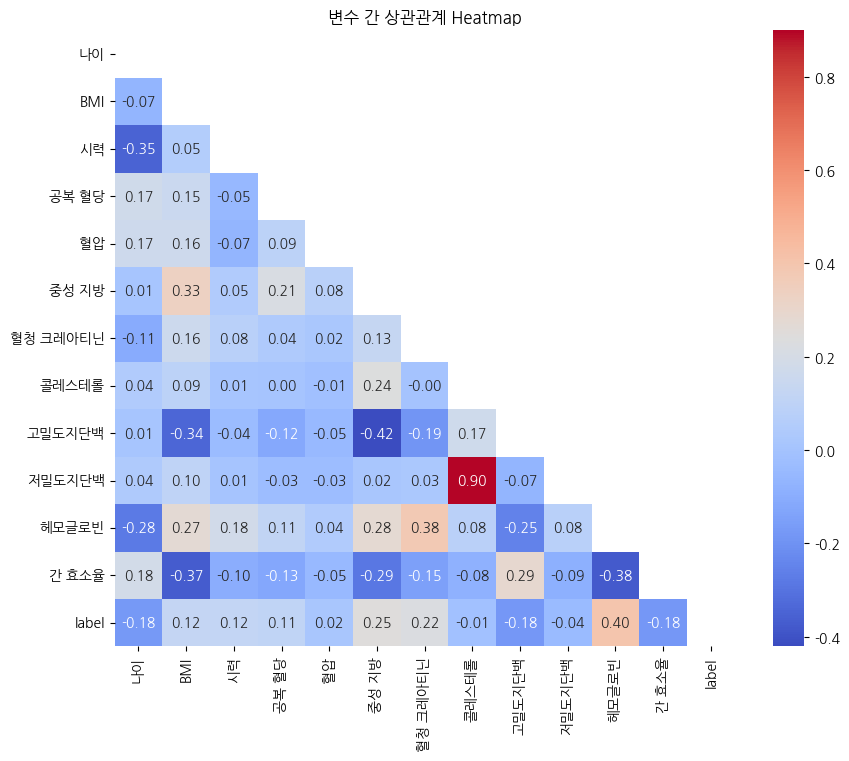

 1. 헤모글로빈               : 0.403
 2. 중성 지방               : 0.247
 3. 혈청 크레아티닌            : 0.225
 4. 간 효소율               : 0.182
 5. 고밀도지단백              : 0.179


In [61]:
#키와 몸무게는 bmi가 포함하고 있는 변수로 상관관계 분석에서 제외
drop_cols = ['키(cm)', '몸무게(kg)']
model_data = health_data.drop(columns=drop_cols)
#label 의 상관분석을 위해 int type으로 재 변환
model_data['label']=model_data['label'].astype(int)

plt.figure(figsize=(10, 8))

corr = model_data.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("변수 간 상관관계 Heatmap")
plt.show()

#label과 상관관계가 높게 나온 top 5 출력
label_corr = corr['label'].abs().sort_values(ascending=False)
for i, (var, corr) in enumerate(label_corr[1:6].items(),1):
    print(f"{i:2d}. {var:<20}: {corr:.3f}")

In [62]:
#흡연유무 그룹별 top5변수들의 평균 비교
health_data.groupby('label')[[
    '헤모글로빈',
    '중성 지방',
    '혈청 크레아티닌',
    '간 효소율',
    '고밀도지단백'
]].mean()

,헤모글로빈,중성 지방,혈청 크레아티닌,간 효소율,고밀도지단백
label,,,,,
0,14.160745,113.472870,0.847028,1.205119,59.308813
1,15.448984,150.589079,0.947790,1.041517,53.943051


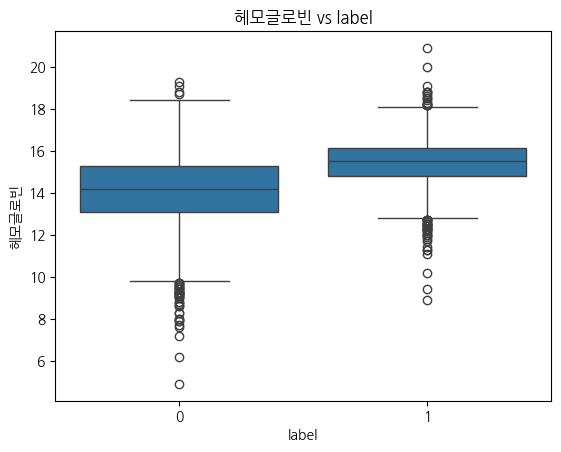

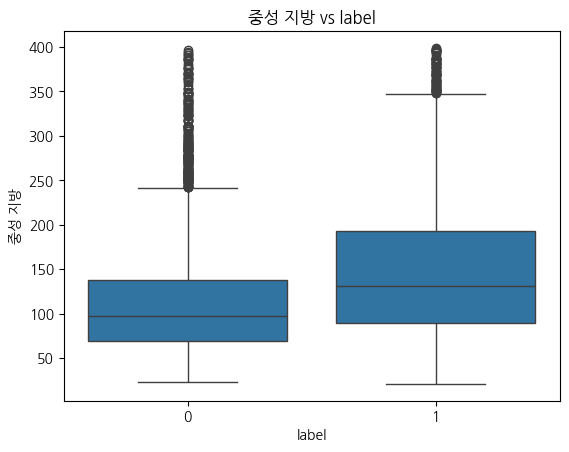

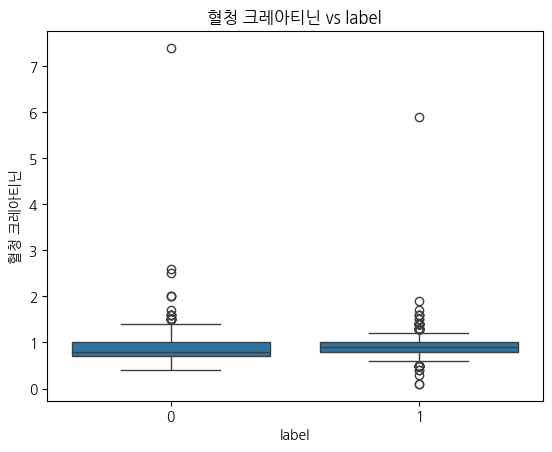

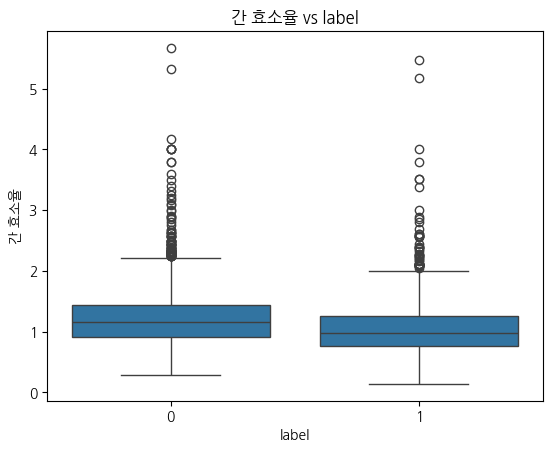

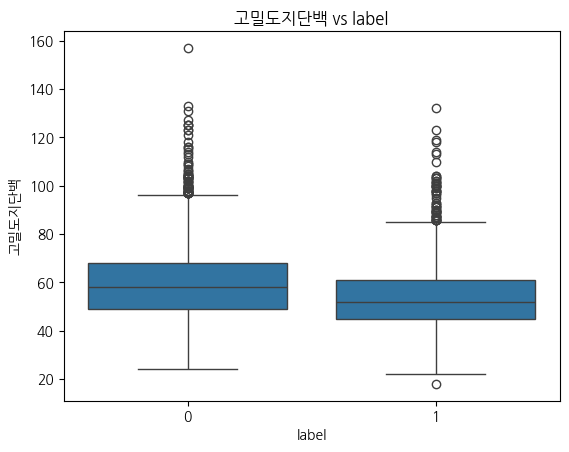

In [63]:
#top 5 변수의 흡연유무 별 boxplot
top_vars = label_corr[1:6].index

for var in top_vars:
    plt.figure()
    sns.boxplot(x='label', y=var, data=model_data)
    plt.title(f"{var} vs label")
    plt.show()

In [64]:
#비슷한 특성을 가진 변수들끼리 상관관계 비교(중복 제거를 위함)
health_data[[
    'BMI',
    '공복 혈당',
    '콜레스테롤',
    '중성 지방',
    '고밀도지단백',
    '저밀도지단백']
].corr()

,BMI,공복 혈당,콜레스테롤,중성 지방,고밀도지단백,저밀도지단백
BMI,1.000000,0.148675,0.094563,0.333656,-0.340850,0.103815
공복 혈당,0.148675,1.000000,0.003286,0.214303,-0.118696,-0.032370
콜레스테롤,0.094563,0.003286,1.000000,0.237973,0.167132,0.899042
중성 지방,0.333656,0.214303,0.237973,1.000000,-0.420722,0.017117
고밀도지단백,-0.340850,-0.118696,0.167132,-0.420722,1.000000,-0.065275
저밀도지단백,0.103815,-0.032370,0.899042,0.017117,-0.065275,1.000000



[카이제곱 검정 결과]
충치              p-value: 7.31681e-15 | Cramér's V: 0.094
요 단백            p-value: 4.86350e-01 | Cramér's V: 0.022
BMI 구간          p-value: 4.36762e-22 | Cramér's V: 0.127
나이대             p-value: 5.80248e-48 | Cramér's V: 0.186


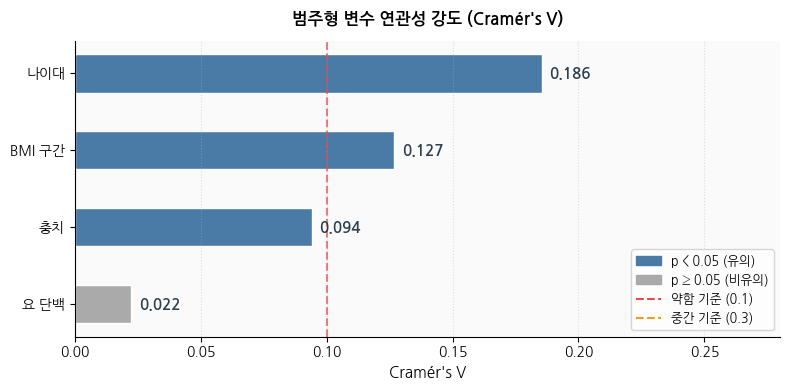

In [82]:
#카이제곱(상관도)과 cramers_v(영향력) 계산 (범주 vs 범주)
def cramers_v(table):
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.sum().sum()
    r, k = table.shape
    v = np.sqrt(chi2 / (n * (min(k-1, r-1))))
    return chi2, p, v


model_data['요 단백'] = model_data['요 단백'].astype('category')
cat_cols = ['충치', '요 단백', 'BMI 구간', '나이대']

print("\n[카이제곱 검정 결과]")

for col in cat_cols:
    table = pd.crosstab(model_data[col], model_data['label'])

    chi2, p, v = cramers_v(table)

    print(f"{col:<15} p-value: {p:.5e} | Cramér's V: {v:.3f}")

results = []
for col in cat_cols:
    table = pd.crosstab(model_data[col], model_data['label'])
    chi2, p, v = cramers_v(table)
    results.append({'변수': col, 'V': v, 'p': p})

df_cat = pd.DataFrame(results).sort_values('V', ascending=True)
colors = ['#4A7BA7' if p < 0.05 else '#AAAAAA' for p in df_cat['p']]

fig, ax = plt.subplots(figsize=(8, 4))
ax.set_facecolor('#FAFAFA')

bars = ax.barh(df_cat['변수'], df_cat['V'], color=colors, height=0.5, edgecolor='white')

# 기준선
ax.axvline(x=0.1, color='#E24B4A', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(x=0.3, color='#E8A020', linestyle='--', linewidth=1.5, alpha=0.7)

# 값 표시
for bar, val in zip(bars, df_cat['V']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11,
            color='#2C3E50', fontweight='bold')

ax.set_xlabel("Cramér's V", fontsize=11)
ax.set_title("범주형 변수 연관성 강도 (Cramér's V)", fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(0, 0.28)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.4)

from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color='#4A7BA7', label='p < 0.05 (유의)'),
    mpatches.Patch(color='#AAAAAA', label='p ≥ 0.05 (비유의)'),
    Line2D([0],[0], color='#E24B4A', linestyle='--', linewidth=1.5, label='약함 기준 (0.1)'),
    Line2D([0],[0], color='#E8A020', linestyle='--', linewidth=1.5, label='중간 기준 (0.3)'),
], loc='lower right', fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.show()

In [66]:
#t_test(상관도), cohens_d(영향력) 계산 (범주 vs 연속)
num_cols = model_data.select_dtypes(include=['float64', 'int64']).columns
num_cols = [c for c in num_cols if c != 'label']

# Cohen's d 함수
def cohens_d(x, y):
    x = x.dropna()
    y = y.dropna()

    nx, ny = len(x), len(y)
    sx, sy = np.var(x, ddof=1), np.var(y, ddof=1)

    pooled_std = np.sqrt(((nx-1)*sx + (ny-1)*sy) / (nx+ny-2))

    return (np.mean(x) - np.mean(y)) / pooled_std


print("\n[t-test + Effect Size 결과]")

for col in num_cols:
    group0 = model_data[model_data['label'] == 0][col]
    group1 = model_data[model_data['label'] == 1][col]

    t_stat, p = ttest_ind(group0, group1, nan_policy='omit')
    d = cohens_d(group0, group1)

    print(f"{col:<15} p-value: {p:.5e} | Cohen's d: {d:.3f}")


[t-test + Effect Size 결과]
나이              p-value: 9.26581e-49 | Cohen's d: 0.371
BMI             p-value: 9.07988e-25 | Cohen's d: -0.259
시력              p-value: 9.44045e-22 | Cohen's d: -0.241
공복 혈당           p-value: 2.16199e-19 | Cohen's d: -0.227
혈압              p-value: 1.72014e-01 | Cohen's d: -0.034
중성 지방           p-value: 2.64222e-95 | Cohen's d: -0.528
혈청 크레아티닌        p-value: 5.29522e-79 | Cohen's d: -0.478
콜레스테롤           p-value: 4.03932e-01 | Cohen's d: 0.021
고밀도지단백          p-value: 3.12301e-50 | Cohen's d: 0.377
저밀도지단백          p-value: 9.42599e-04 | Cohen's d: 0.083
헤모글로빈           p-value: 6.03355e-265 | Cohen's d: -0.913
간 효소율           p-value: 7.17541e-52 | Cohen's d: 0.383


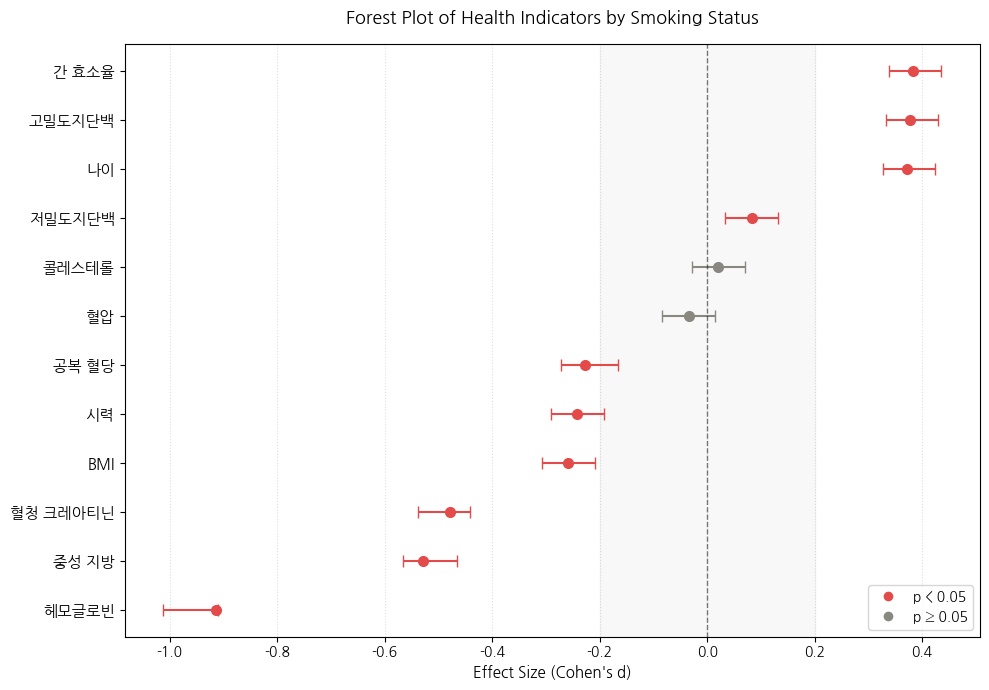

In [70]:
# ── Forest Plot (t-test 결과 시각화) ──────────────────────────
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind, t

plot_data = []
for col in num_cols:
    g0 = model_data[model_data['label'] == 0][col].dropna()
    g1 = model_data[model_data['label'] == 1][col].dropna()

    d = cohens_d(g0, g1)
    _, p = ttest_ind(g0, g1, nan_policy='omit')

    # 신뢰구간 계산
    se = np.sqrt(g0.var(ddof=1)/len(g0) + g1.var(ddof=1)/len(g1))
    margin = t.ppf(0.975, df=len(g0)+len(g1)-2) * se
    std_pool = (g0.std(ddof=1) + g1.std(ddof=1)) / 2
    lo_d = (g0.mean() - g1.mean() - margin) / std_pool
    hi_d = (g0.mean() - g1.mean() + margin) / std_pool

    plot_data.append({'변수': col, 'd': d, 'lo': lo_d, 'hi': hi_d, 'p': p})

df_plot = pd.DataFrame(plot_data).sort_values('d')
colors = ['#E24B4A' if row['p'] < 0.05 else '#888780' for _, row in df_plot.iterrows()]

fig, ax = plt.subplots(figsize=(10, 7))
for i, (_, row) in enumerate(df_plot.iterrows()):
    ax.errorbar(x=row['d'], y=i,
            xerr=[[abs(row['d'] - row['lo'])], [abs(row['hi'] - row['d'])]],
            fmt='o', color=colors[i], ecolor=colors[i],
            capsize=4, markersize=7, linewidth=1.5)

ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axvspan(-0.2, 0.2, alpha=0.05, color='gray')
ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot['변수'], fontsize=11)
ax.set_xlabel("Effect Size (Cohen's d)", fontsize=11)
ax.set_title("Forest Plot of Health Indicators by Smoking Status", fontsize=13, pad=15)
ax.grid(axis='x', linestyle=':', alpha=0.4)
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E24B4A', markersize=8, label='p < 0.05'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#888780', markersize=8, label='p ≥ 0.05'),
], loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

## 이변량 분석 결과 요약

### 1. 범주형 변수와 흡연 여부 — 카이제곱 검정

카이제곱 검정 결과, 충치·BMI 구간·나이대는 흡연 여부와 통계적으로 유의한 연관성을 보였다(p < 0.05). 단, Cramér's V 기준으로는 전반적으로 약한 수준의 관계에 해당한다.

| 변수 | p-value | Cramér's V | 효과 크기 | 유의성 |
|------|---------|------------|-----------|--------|
| 나이대 | 5.80e-48 | 0.186 | 약함 | ✓ 유의 |
| BMI 구간 | 4.37e-22 | 0.127 | 약함 | ✓ 유의 |
| 충치 | 7.32e-15 | 0.094 | 약함 | ✓ 유의 |
| 요 단백 | 0.486 | 0.022 | 무시 가능 | ✗ 비유의 |

> ※ Cramér's V 해석 기준: V < 0.1 — 무시 가능 / 0.1 이상 0.3 미만 — 약함 / 0.3 이상 0.5 미만 — 중간 / 0.5 이상 — 강함

일부 변수는 통계적으로 유의하지만 V 값이 모두 0.2 미만으로 설명력은 제한적이다. 요 단백은 통계적으로도 유의하지 않아 흡연 여부와의 연관성이 낮다.

---

### 2. 연속형 변수와 흡연 여부 — t-test + Cohen's d

t-test 및 Cohen's d 분석 결과, 일부 생리적 지표에서 흡연 여부에 따른 차이가 관찰되었다.
Cohen's d는 그룹0(비흡연자) − 그룹1(흡연자)으로 산출되었으므로, d < 0이면 흡연자가, d > 0이면 비흡연자가 더 높은 값을 가진다.

**① 중간~강한 효과 크기 (|d| ≥ 0.5)**

| 변수 | p-value | Cohen's d | 효과 크기 | 방향 |
|------|---------|-----------|-----------|------|
| 헤모글로빈 | 6.03e-265 | -0.913 | 강함 | 흡연자 ↑ |
| 중성 지방 | 2.64e-95 | -0.528 | 중간 | 흡연자 ↑ |
| 혈청 크레아티닌 | 5.30e-79 | -0.478 | 중간 | 흡연자 ↑ |

**② 약한 효과 크기 (0.2 ≤ |d| < 0.5)**

| 변수 | p-value | Cohen's d | 효과 크기 | 방향 |
|------|---------|-----------|-----------|------|
| 간 효소율 | 7.18e-52 | 0.383 | 약함 | 비흡연자 ↑ |
| 고밀도지단백(HDL) | 3.12e-50 | 0.377 | 약함 | 비흡연자 ↑ |
| 나이 | 9.27e-49 | 0.371 | 약함 | 비흡연자 ↑ |
| BMI | 9.08e-25 | -0.259 | 약함 | 흡연자 ↑ |
| 시력 | 9.44e-22 | -0.241 | 약함 | 흡연자 ↑ |
| 공복 혈당 | 2.16e-19 | -0.227 | 약함 | 흡연자 ↑ |

**③ 통계적으로 유의하지 않은 변수**

| 변수 | p-value | Cohen's d | 효과 크기 |
|------|---------|-----------|-----------|
| 혈압 | 0.172 | -0.034 | 무시 가능 |
| 콜레스테롤 | 0.404 | 0.021 | 무시 가능 |
| 저밀도지단백(LDL) | 9.43e-04 | 0.083 | 무시 가능 |

> ※ Cohen's d 해석 기준: |d| < 0.2 — 무시 가능 / 0.2 이상 0.5 미만 — 약함 / 0.5 이상 0.8 미만 — 중간 / 0.8 이상 — 강함

---

### 3. 방향성 해석

**d < 0 — 흡연자가 더 높은 값:** 헤모글로빈, 중성 지방, 혈청 크레아티닌, BMI, 공복 혈당, 시력
> ※ 헤모글로빈 상승은 흡연으로 인한 일산화탄소 흡수로 체내 보상 반응이 일어나기 때문으로, 단순 '건강한 상승'으로 해석해선 안 된다.

**d > 0 — 비흡연자가 더 높은 값:** HDL(고밀도지단백), 나이, 간 효소율
> ※ HDL이 비흡연자에서 더 높게 나타난 것은 흡연이 심혈관 건강에 부정적 영향을 미친다는 기존 연구와 일치한다.

---

### 4. 종합 해석

흡연 여부는 일부 건강 지표와 통계적으로 유의한 관계를 보였으나, 대부분의 변수에서 효과 크기는 약하거나 중간 수준에 머물렀다.

특히 헤모글로빈(d = -0.913)은 강한 효과 크기를 보였고, 중성 지방·혈청 크레아티닌도 중간 이상의 차이를 나타냈다. 반면 혈압·콜레스테롤은 통계적 유의성도 없어 흡연과의 연관성이 낮은 것으로 보인다.

따라서 흡연은 특정 생리적 지표(헤모글로빈, 중성 지방, 크레아티닌 등)에는 의미 있는 영향을 미치나, 전반적인 건강 지표를 설명하는 단독 강력 요인으로 보기는 어렵다. 이후 예측 모델 구축 시, 효과 크기가 큰 변수를 우선 특성(feature)으로 고려하는 것이 유효할 것이다.